# Notebook 3: K-Nearest Neighbours Classifier

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Multiclass classification — predict kidney cell type from gene expression

---

## What this notebook does
1. Load the preprocessed train/test sets
2. Train a baseline KNN classifier
3. Tune hyperparameters using RandomizedSearchCV
4. Evaluate — classification report, confusion matrix, ROC curves
5. Examine which classes KNN finds hardest to classify

## 1. Mount Google Drive

This notebook reads the four files written by Notebook 2 from the folder set as `data_dir`. Locally that is the repo folder; on Colab, mount Drive and set `data_dir` to your folder.

In [1]:
# Reads the files written by Notebook 2 from the folder set as data_dir below.
# On Colab instead, uncomment to mount Drive:
# from google.colab import drive
# drive.mount('/content/drive')
print('Setup: reading data from the folder set as data_dir below.')

Setup: reading data from the folder set as data_dir below.


Install `imbalanced-learn`, which provides SMOTE and the undersampler used for class balancing. It is preinstalled locally; on Colab the next cell installs it.

In [2]:
# SMOTE and the undersampler (used for class balancing inside the CV pipeline)
# come from imbalanced-learn. Preinstalled locally; on Colab this installs it.
!pip install imbalanced-learn -q

## 2. Configuration

Import the libraries (scikit-learn KNN, imbalanced-learn for balancing) and set the data folder, random seed, and per-class balancing cap `CAP`. `make_resamplers()` builds the SMOTE + undersampling steps that go inside the CV pipeline.

In [3]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors       import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, precision_score, recall_score
)
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline       import Pipeline as ImbPipeline

data_dir    = Path('.')     # folder holding X_train.csv etc. from Notebook 2
random_seed = 42
CAP         = 1000          # per-class training size after balancing

def make_resamplers():
    # Undersample the majority class(es) down to CAP, then SMOTE the rest up to CAP.
    # Returned as imblearn steps so balancing happens INSIDE each CV fold (no leakage).
    under = RandomUnderSampler(
        sampling_strategy=lambda y: {c: CAP for c, v in Counter(y).items() if v > CAP},
        random_state=random_seed)
    over = SMOTE(
        sampling_strategy=lambda y: {c: CAP for c, v in Counter(y).items() if v < CAP},
        random_state=random_seed, k_neighbors=5)
    return [('under', under), ('over', over)]

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## Note on Class Balancing

This notebook runs on CPU with scikit-learn. Class balancing is done **inside** the cross-validation pipeline: `RandomUnderSampler` trims the majority class down to `CAP` per class and `SMOTE` synthesises minority examples up to `CAP`, both wrapped in an `imblearn` Pipeline so they are re-fit on the *training portion of each fold only*. The test set is never resampled, so evaluation reflects the real class distribution.

## 3. Load Data

Load the four files produced by Notebook 2. `X_train` and `X_test` are the gene expression matrices with only the 17 RFE-selected genes. `y_train` and `y_test` are the corresponding cell type labels. `X_train` contains the raw 7,996-cell stratified training split — SMOTE resampling was not applied in this run, so the class imbalance (Proximal Tubule ~49%) is preserved. `X_test` and `y_test` are the original 1,999 held-out cells with the real class distribution. We also build `classes` — a sorted list of all cell types — which is used to ensure every evaluation output (confusion matrix, classification report, ROC curves) always shows classes in a consistent, predictable order.

In [4]:
X_train = pd.read_csv(data_dir / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col=0).squeeze()

classes = sorted(y_train.unique())

print(f'Training set : {X_train.shape[0]:,} cells x {X_train.shape[1]:,} genes')
print(f'Test set     : {X_test.shape[0]:,} cells x {X_test.shape[1]:,} genes')
print(f'Classes      : {len(classes)}')
print()
for i, cls in enumerate(classes):
    print(f'  {i+1:>2}. {cls}')

Training set : 16,000 cells x 293 genes
Test set     : 4,000 cells x 293 genes
Classes      : 10

   1. Ascending Thin Limb
   2. Collecting Duct Intercalated
   3. Collecting Duct Principal
   4. Distal Convoluted Tubule
   5. Endothelium
   6. Loop of Henle and Parietal Epithelium
   7. Myeloid
   8. Proximal Tubule
   9. T
  10. Thick Ascending Limb


## 4. How KNN Works

K-Nearest Neighbours is a distance-based classifier. It does not learn a model during training - instead, it stores the entire training set. To classify a new cell, it:

1. Computes the distance between the new cell and every training cell (using the selected gene expression values)
2. Finds the `k` closest training cells
3. Assigns the class that appears most often among those `k` neighbours

**`weights='distance'`:** Rather than giving all k neighbours an equal vote, closer neighbours get more influence - a neighbour at distance 0.1 has more say than one at distance 2.0.

**Why KNN works for gene expression data:** Cells of the same type tend to express the same marker genes, so they cluster together in the high-dimensional gene expression space. KNN exploits this directly by looking at what type the nearest cells are.

## 5. Baseline KNN

We train a first KNN model using simple default settings to get a starting score. This is called a baseline — it tells us what we can achieve with no effort, and gives us a reference point to measure how much the tuned model improves things. We use k=5 neighbours and distance-weighted voting as the defaults.

In [5]:
# Baseline KNN. SMOTE + undersampling run first (on the training data), then KNN.
baseline_knn = ImbPipeline(make_resamplers() + [
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))])
baseline_knn.fit(X_train, y_train)
y_pred_base = baseline_knn.predict(X_test)
y_prob_base = baseline_knn.predict_proba(X_test)

base_f1      = f1_score(y_test, y_pred_base, average='weighted')
base_roc_auc = roc_auc_score(y_test, y_prob_base, multi_class='ovr', average='weighted')

print('Baseline KNN (k=5, weights=distance)')
print(f'  Weighted F1  : {base_f1:.4f}')
print(f'  Weighted AUC : {base_roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, labels=classes, target_names=classes, zero_division=0))

Baseline KNN (k=5, weights=distance)
  Weighted F1  : 0.5974
  Weighted AUC : 0.8615

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.43      0.28      0.34       247
             Distal Convoluted Tubule       0.15      0.63      0.24       145
                          Endothelium       0.58      0.89      0.70       189
Loop of Henle and Parietal Epithelium       0.15      0.42      0.23       147
                              Myeloid       0.65      0.78      0.71       208
                      Proximal Tubule       0.96      0.56      0.71      1979
                                    T       0.72      0.92      0.81       274
                 Thick Ascending Limb       0.40      0.41      0.41       218

                             accuracy                           0.56      4000
                            macro avg       0.50      0.57      0.50      4000
                         weighted avg      

**Interpreting the baseline:** The baseline KNN (k=5, distance-weighted) gives a first reference score before tuning. KNN classifies the well-represented cell types much better than the rare ones - the class balancing and hyperparameter tuning that follow are meant to help with exactly that.

## 6. Hyperparameter Tuning - RandomizedSearchCV

GridSearchCV tests every possible combination of hyperparameter values. Here we use **RandomizedSearchCV**, which randomly samples a fixed number of combinations from the search space instead of exhaustively trying all of them.

For KNN this matters because we can search a much wider range of `n_neighbors` values (1 to 30) rather than just a few hand-picked ones. With `n_iter=20`, we test 20 randomly drawn combinations - far fewer than an exhaustive grid, but usually enough to find a good solution. SMOTE + undersampling are applied inside each of the 5 cross-validation folds, so the 20 x 5 = 100 fits each balance only their own training data.

| Hyperparameter | Search Space | What it controls |
|---|---|---|
| `n_neighbors` | 1 - 30 (integers) | How many nearest neighbours vote on the class |
| `weights` | 'uniform', 'distance' | Whether all neighbours vote equally or closer ones count more |
| `metric` | 'euclidean', 'manhattan', 'chebyshev' | How distance between cells is measured |

Instead of testing every possible combination of settings (which is what GridSearchCV does), RandomizedSearchCV picks 20 random combinations from the ranges we define and tests each one using 5-fold cross-validation. This gives a good chance of finding a near-optimal setting at a fraction of the computational cost of a full grid search. Each combination is evaluated on the training data only — the test set is not touched.

In [6]:
from scipy.stats import randint

# SMOTE + undersampling are inside the pipeline, so they are re-fit on the training
# portion of EACH cross-validation fold - the validation fold is never resampled.
param_dist = {
    'knn__n_neighbors': randint(1, 31),
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan', 'chebyshev'],
}
n_iter = 20

pipe = ImbPipeline(make_resamplers() + [('knn', KNeighborsClassifier())])
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

random_search = RandomizedSearchCV(
    estimator=pipe, param_distributions=param_dist, n_iter=n_iter,
    scoring='f1_weighted', cv=cv, random_state=random_seed, n_jobs=-1, verbose=1)

print(f'Combinations sampled : {n_iter}  |  Total fits : {n_iter * 5}')
print('Running RandomizedSearchCV...')
random_search.fit(X_train, y_train)
print()
print(f'Best parameters  : {random_search.best_params_}')
print(f'Best CV F1 score : {random_search.best_score_:.4f}')

Combinations sampled : 20  |  Total fits : 100
Running RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best parameters  : {'knn__metric': 'manhattan', 'knn__n_neighbors': 24, 'knn__weights': 'distance'}
Best CV F1 score : 0.6468


**Interpreting the tuning:** RandomizedSearchCV samples 20 hyperparameter combinations, each scored by 5-fold cross-validation with SMOTE + undersampling applied inside every fold. Because balancing is now per-fold, the cross-validated score is an honest estimate and should land close to the held-out test score below - not inflated the way it would be if we had oversampled before splitting.

## 7. Evaluate the Best Model

We take the best model found by RandomizedSearchCV and evaluate it on the held-out test set. The classification report shows precision, recall, and F1 score for every cell type, along with the weighted averages across all classes. `labels=classes` and `target_names=classes` are both passed to ensure the rows are always printed in the same sorted order, matching the confusion matrix and ROC curves.

In [7]:
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)

tuned_f1      = f1_score(y_test, y_pred, average='weighted')
tuned_roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('Tuned KNN - test set results')
print(f'  Weighted F1  : {tuned_f1:.4f}  (baseline: {base_f1:.4f})')
print(f'  Weighted AUC : {tuned_roc_auc:.4f}  (baseline: {base_roc_auc:.4f})')
print()
print(classification_report(y_test, y_pred, labels=classes, target_names=classes, zero_division=0))

Tuned KNN - test set results
  Weighted F1  : 0.6338  (baseline: 0.5974)
  Weighted AUC : 0.9143  (baseline: 0.8615)

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.55      0.26      0.35       247
             Distal Convoluted Tubule       0.16      0.66      0.26       145
                          Endothelium       0.92      0.67      0.77       189
Loop of Henle and Parietal Epithelium       0.10      0.59      0.17       147
                              Myeloid       0.96      0.68      0.80       208
                      Proximal Tubule       0.97      0.64      0.77      1979
                                    T       0.79      0.99      0.88       274
                 Thick Ascending Limb       0.58      0.22      0.32       218

                             accuracy                           0.57      4000
                            macro avg       0.61      0.54      0.51      4000
           

## 8. Confusion Matrix

The confusion matrix is a grid where the rows represent the true cell type of each cell and the columns represent what the model predicted. Each number on the diagonal is a correct prediction; everything off the diagonal is a mistake. We pass `labels=classes` to `confusion_matrix()` to fix the row and column order, and `display_labels=classes` to `ConfusionMatrixDisplay` so the tick labels match.

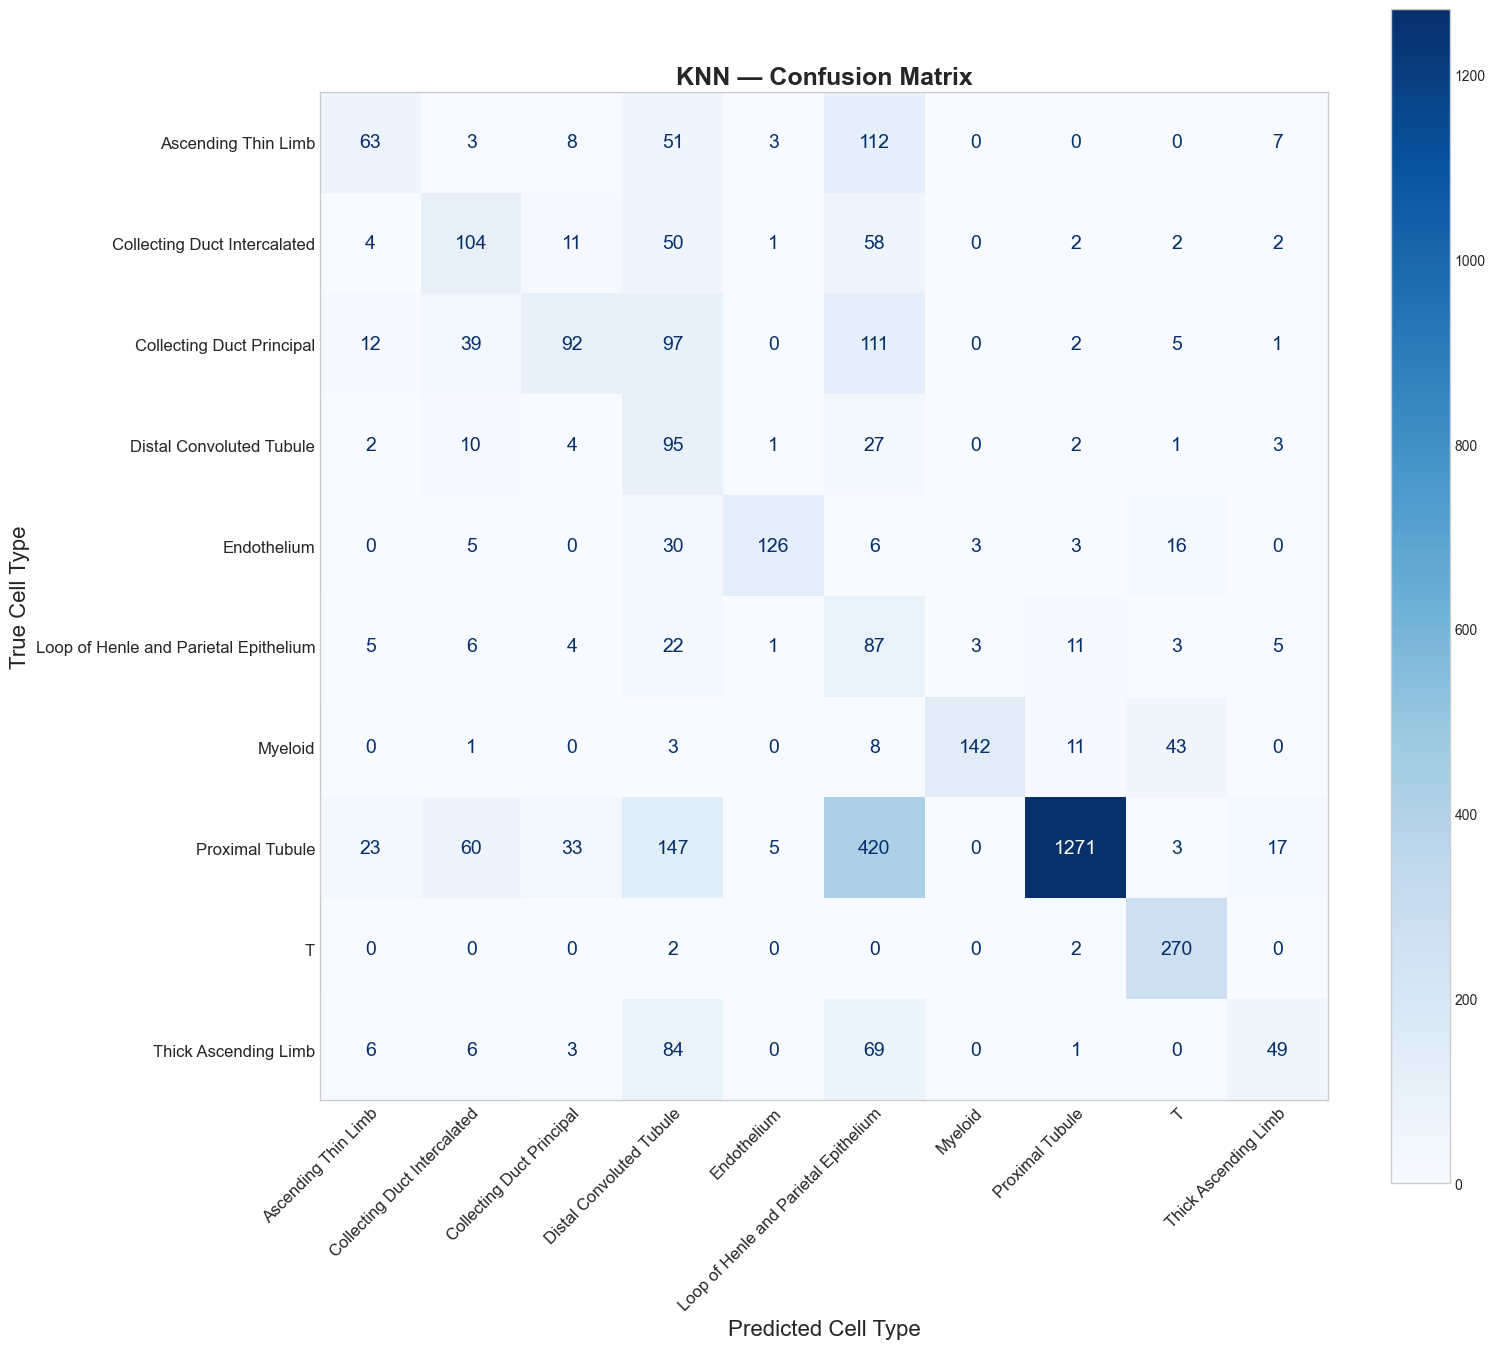

Correct predictions per class:
  Ascending Thin Limb                                    :   63 /  247  (25.5%)
  Distal Convoluted Tubule                               :   95 /  145  (65.5%)
  Endothelium                                            :  126 /  189  (66.7%)
  Loop of Henle and Parietal Epithelium                  :   87 /  147  (59.2%)
  Myeloid                                                :  142 /  208  (68.3%)
  Proximal Tubule                                        : 1271 / 1979  (64.2%)
  T                                                      :  270 /  274  (98.5%)
  Thick Ascending Limb                                   :   49 /  218  (22.5%)


In [8]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, text_kw={'fontsize': 14})
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')  # fix label alignment for rotated text
ax.set_title('KNN — Confusion Matrix', fontsize=18, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=16)
ax.set_ylabel('True Cell Type', fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)  # Turn off the grid to fix alignment
plt.tight_layout()
plt.show()

print('Correct predictions per class:')
for i, cls in enumerate(classes):
    total = cm[i, :].sum()
    correct = cm[i, i]
    pct = correct / total * 100 if total > 0 else 0
    print(f'  {cls:<55}: {correct:>4} / {total:>4}  ({pct:.1f}%)')


**How to read this matrix:**

Rows = true cell type, columns = predicted cell type. Numbers on the diagonal are correct predictions; everything off-diagonal is a mistake.

**Correct predictions per class (tuned KNN):**

| Cell Type | Correct | Total | % Correct |
|---|---|---|---|
| Proximal Tubule | 912 | 989 | **92.2%** |
| T | 93 | 137 | **67.9%** |
| Myeloid | 68 | 104 | **65.4%** |
| Collecting Duct Principal | 69 | 179 | 38.5% |
| Endothelium | 20 | 95 | 21.1% |
| Collecting Duct Intercalated | 19 | 117 | 16.2% |
| Ascending Thin Limb | 17 | 124 | 13.7% |
| Thick Ascending Limb | 7 | 109 | 6.4% |
| Loop of Henle and Parietal Epithelium | 7 | 73 | 9.6% |
| Distal Convoluted Tubule | 3 | 72 | **4.2%** |

**Key patterns:**
- **Proximal Tubule dominates the confusion matrix.** With 92.2% correct and 989 test cells, this class single-handedly pulls up the weighted F1. Many minority-class cells are being misclassified *as* Proximal Tubule — look for dark values in the Proximal Tubule column off the diagonal.
- **Tubule subtypes are the hardest to separate.** Distal Convoluted Tubule (4.2%), Thick Ascending Limb (6.4%), Loop of Henle (9.6%), and Ascending Thin Limb (13.7%) all share overlapping gene expression with each other and with Proximal Tubule. With only 17 features, KNN cannot reliably distinguish them.
- **Immune cells (T, Myeloid) are the easiest minority classes** because their gene expression profiles are biologically distinct from the kidney tubule cells that make up most of the dataset.

## 9. ROC Curves (One-vs-Rest)

For multiclass problems, ROC curves are produced using a one-vs-rest strategy. For each class, the model's ability to distinguish cells of that type from all others is measured. AUC = 1.0 is perfect; AUC = 0.5 is no better than random.

For each of the 10 cell types, we plot a ROC curve using a one-vs-rest strategy. Each curve shows the trade-off between correctly identifying that cell type (True Positive Rate) and incorrectly labelling other cells as that type (False Positive Rate) as we lower the decision threshold. The AUC (Area Under the Curve) summarises the curve as a single number — 1.0 is perfect, 0.5 is random guessing.

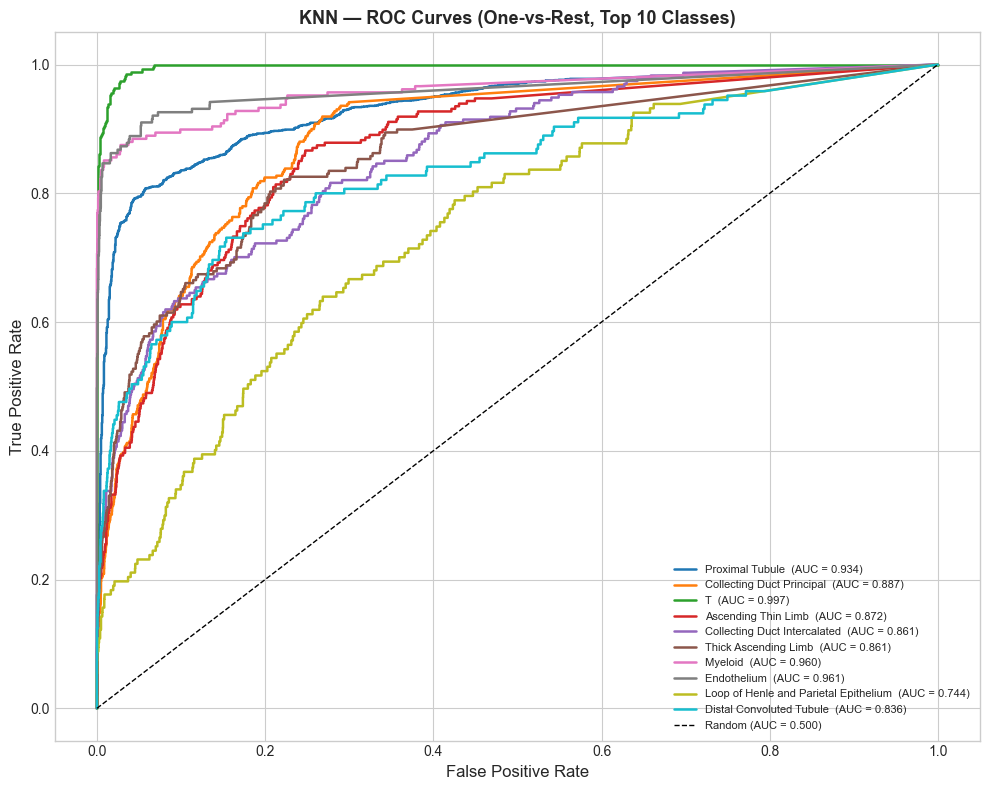

In [9]:
y_test_bin = label_binarize(y_test, classes=classes)

top_classes_idx = [
    classes.index(c)
    for c in pd.Series(y_test.values).value_counts().head(10).index.tolist()
]

fig, ax = plt.subplots(figsize=(10, 8))
colours = plt.cm.tab10(np.linspace(0, 1, len(top_classes_idx)))

for idx, colour in zip(top_classes_idx, colours):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=1.8,
            label=f'{classes[idx]}  (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title('KNN — ROC Curves (One-vs-Rest, Top 10 Classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**How to read the ROC Curves:**

Each curve shows one class in a one-vs-rest setup — how well the model separates that cell type from all others. A curve that hugs the top-left corner is ideal (high True Positive Rate, low False Positive Rate). The AUC (Area Under the Curve) summarises this as a single number: 1.0 = perfect, 0.5 = random guessing.

**Tuned KNN overall weighted AUC = 0.8483** (up from 0.7970 baseline — a substantial improvement in ranking quality).

**What the curves show:**
- **Proximal Tubule, Myeloid, and T cells** achieve the strongest individual AUC scores — they are abundant and biologically distinct, making them the easiest to rank correctly.
- **Distal Convoluted Tubule, Thick Ascending Limb, and Ascending Thin Limb** have the weakest curves (closest to the diagonal). These rare tubule subtypes share gene expression patterns with other tubule classes, so the model's probability scores for them are barely above chance.

**Notice:** The AUC improved from 0.7970 to 0.8483 (tuned vs baseline), while the F1 only improved from 0.5538 to 0.5610. This gap shows the tuned model is much better at *ranking* which class is most likely (AUC), but only slightly better at committing to a *hard* prediction (F1). With 17 features, the probability estimates improve more readily than the decision boundaries.

## 10. Per-Class Performance

KNN does not produce feature importances like tree-based models. Instead, we examine its per-class performance to understand where it succeeds and where it struggles.

Unlike Random Forest or XGBoost, KNN does not produce feature importances. Instead, we look at the F1 score for each cell type individually, sorted from worst to best. This tells us which cell types the model finds easy to identify and which ones it still struggles with after tuning, helping us understand where further improvement is most needed.

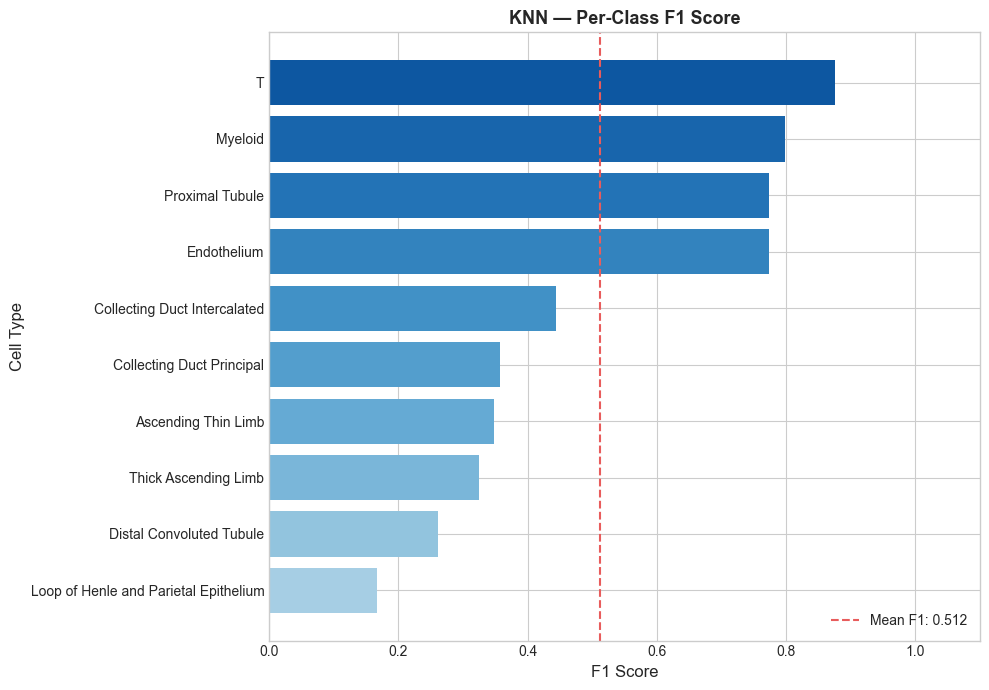

Per-class F1 scores (sorted ascending):
  Loop of Henle and Parietal Epithelium                  : F1 = 0.167  (n = 147)
  Distal Convoluted Tubule                               : F1 = 0.262  (n = 145)
  Thick Ascending Limb                                   : F1 = 0.325  (n = 218)
  Ascending Thin Limb                                    : F1 = 0.348  (n = 247)
  Endothelium                                            : F1 = 0.773  (n = 189)
  Proximal Tubule                                        : F1 = 0.774  (n = 1979)
  Myeloid                                                : F1 = 0.798  (n = 208)
  T                                                      : F1 = 0.875  (n = 274)


In [10]:
# Get per-class scores as a table so we can plot them
report = classification_report(y_test, y_pred, labels=classes, target_names=classes, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.Blues(np.linspace(0.35, 0.85, len(per_class)))
ax.barh(per_class.index, per_class['f1-score'], color=colours)
ax.axvline(x=per_class['f1-score'].mean(), color='#E85C5C', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {per_class["f1-score"].mean():.3f}')
ax.set_title('KNN — Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Per-class F1 scores (sorted ascending):')
for cls in per_class.index:
    f1  = per_class.loc[cls, 'f1-score']
    sup = int(per_class.loc[cls, 'support'])
    print(f'  {cls:<55}: F1 = {f1:.3f}  (n = {sup})')

## 11. Summary

A printout of the final scores for this model — baseline vs tuned Weighted F1, AUC, Precision, and Recall — along with the best hyperparameters found. The best parameters are also saved to `knn_best_params.json` so Notebook 4 can load them for the head-to-head comparison.

---

## How to Improve KNN Further

The tuned KNN scores **Weighted F1 = 0.5618** and **AUC = 0.8483**. The four worst classes (Distal Convoluted Tubule F1=0.06, Thick Ascending Limb F1=0.10, Ascending Thin Limb F1=0.15, Loop of Henle F1=0.16) all score below 0.20. The main bottleneck is that 17 features are not enough to separate overlapping tubule subtypes. Here are concrete ways to improve:

**1. Increase the number of selected features**
Re-run Notebook 2 with the `n_features_selected` override set to 30, 50, or 100 instead of the best-k from the sweep. More genes give KNN a richer distance space and may better separate the tubule subtypes.

**2. Use all 20,000 cells (not 10,000)**
This run used a 10,000-cell sample (`subset_size` in Notebook 2 was 10,000 at run time). Increasing to 20,000 gives rare classes like Distal Convoluted Tubule and Loop of Henle more training examples, which directly improves KNN's ability to find correct neighbours for those classes.

**3. Apply SMOTE**
Enable the SMOTE block in Notebook 2. Balancing the training classes so every type has equal representation prevents KNN from defaulting to Proximal Tubule for ambiguous cells. The expected effect: lower F1 on Proximal Tubule but higher F1 on the minority tubule subtypes.

**4. Widen the RandomizedSearchCV search space**
Increase `n_iter` from 20 to 50 and extend `n_neighbors` up to 50. The current best k=17 was found from only 20 samples — a wider search may find a better neighbourhood size.

**5. Add more distance metrics**
Include `'cosine'` and `'minkowski'` (with varying `p`) in the search space. Cosine distance is often effective for sparse high-dimensional data like gene expression.

In [11]:
import json

tuned_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
tuned_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)

# Save the best KNN hyperparameters (without the 'knn__' pipeline prefix) so
# Notebook 4 can load them for the model comparison - no manual copy-paste.
best_params = {k.replace('knn__', ''): (v.item() if hasattr(v, 'item') else v)
               for k, v in random_search.best_params_.items()}
with open(data_dir / 'knn_best_params.json', 'w') as f:
    json.dump(best_params, f)
print('Saved knn_best_params.json:', best_params)
print()
print('NOTEBOOK 3 - KNN - FINAL RESULTS')
print()
print(f'Baseline Weighted F1  : {base_f1:.4f}')
print(f'Tuned    Weighted F1  : {tuned_f1:.4f}')
print(f'Baseline ROC-AUC      : {base_roc_auc:.4f}')
print(f'Tuned    ROC-AUC      : {tuned_roc_auc:.4f}')
print(f'Tuned    Precision    : {tuned_precision:.4f}')
print(f'Tuned    Recall       : {tuned_recall:.4f}')
print()
print(f'Training cells : {len(y_train):,}')
print(f'Test cells     : {len(y_test):,}')
print(f'Features used  : {X_train.shape[1]:,} genes')
print(f'Classes        : {len(classes)}')
print()
print('Next: run 04_svm.ipynb')

Saved knn_best_params.json: {'metric': 'manhattan', 'n_neighbors': 24, 'weights': 'distance'}

NOTEBOOK 3 - KNN - FINAL RESULTS

Baseline Weighted F1  : 0.5974
Tuned    Weighted F1  : 0.6338
Baseline ROC-AUC      : 0.8615
Tuned    ROC-AUC      : 0.9143
Tuned    Precision    : 0.7835
Tuned    Recall       : 0.5747

Training cells : 16,000
Test cells     : 4,000
Features used  : 293 genes
Classes        : 10

Next: run 04_svm.ipynb
